In [19]:
import pandas as pd

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

In [20]:
df = pd.read_csv(
    "../data/raw/Student_performance_data _ (1).csv"
)

In [21]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [22]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='str')

In [23]:
df["SupportScore"] = (
    df["Tutoring"] +
    df["ParentalSupport"]
)

In [24]:
df["ActivityScore"] = (
    df["Extracurricular"] +
    df["Sports"] +
    df["Music"] +
    df["Volunteering"]
)

In [25]:
df["AbsenceRatio"] = (
    df["Absences"] /
    (df["Absences"].max())
)

In [26]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,SupportScore,ActivityScore,AbsenceRatio
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0,3,1,0.241379
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0,1,0,0.000000
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0,2,0,0.896552
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0,3,1,0.482759
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0,4,0,0.586207


In [27]:
categorical_cols = df.select_dtypes(
    include=['object']
).columns

In [28]:
categorical_cols

Index([], dtype='str')

In [29]:
X = df.drop("GPA", axis=1)

y = df["GPA"]

In [30]:
numerical_cols = X.columns

In [31]:
scaler = StandardScaler()

In [32]:
X_scaled = scaler.fit_transform(X)

In [33]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [34]:
X_scaled.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass,SupportScore,ActivityScore,AbsenceRatio
0,-1.731327,0.472919,0.978492,-0.853391,0.253711,1.780336,-0.890822,1.522371,-0.108744,-0.788476,-0.660132,2.019544,-0.431866,-0.797387,0.475510,-0.048231,-0.890822
1,-1.729879,1.362944,-1.021981,-0.853391,-0.746087,0.997376,-1.717694,-0.656870,-0.999551,-0.788476,-0.660132,-0.495161,-0.431866,-1.607990,-1.174119,-1.225463,-1.717694
2,-1.728430,-1.307132,-1.021981,1.091641,1.253509,-0.984045,1.353542,-0.656870,-0.108744,-0.788476,-0.660132,-0.495161,-0.431866,0.823819,-0.349305,-1.225463,1.353542
3,-1.726982,0.472919,0.978492,-0.853391,1.253509,0.045445,-0.063951,-0.656870,0.782063,1.268269,-0.660132,-0.495161,-0.431866,0.013216,0.475510,-0.048231,-0.063951
4,-1.725534,0.472919,0.978492,-0.853391,0.253711,-0.902311,0.290422,1.522371,0.782063,-0.788476,-0.660132,-0.495161,-0.431866,0.823819,1.300324,-1.225463,0.290422


In [35]:
print(X_scaled.shape)

(2392, 17)


In [36]:
df[[
    "SupportScore",
    "ActivityScore",
    "AbsenceRatio"
]].head()

,SupportScore,ActivityScore,AbsenceRatio
0,3,1,0.241379
1,1,0,0.000000
2,2,0,0.896552
3,3,1,0.482759
4,4,0,0.586207


In [37]:
corr = df.corr(
    numeric_only=True
)["GPA"].sort_values(
    ascending=False
)

corr

GPA                  1.000000
SupportScore         0.231567
ParentalSupport      0.190774
StudyTimeWeekly      0.179275
Tutoring             0.145119
ActivityScore        0.120884
Extracurricular      0.094078
Music                0.073318
Sports               0.057859
Ethnicity            0.027760
Volunteering         0.003258
Age                  0.000275
StudentID           -0.002697
Gender              -0.013360
ParentalEducation   -0.035854
GradeClass          -0.782835
AbsenceRatio        -0.919314
Absences            -0.919314
Name: GPA, dtype: float64

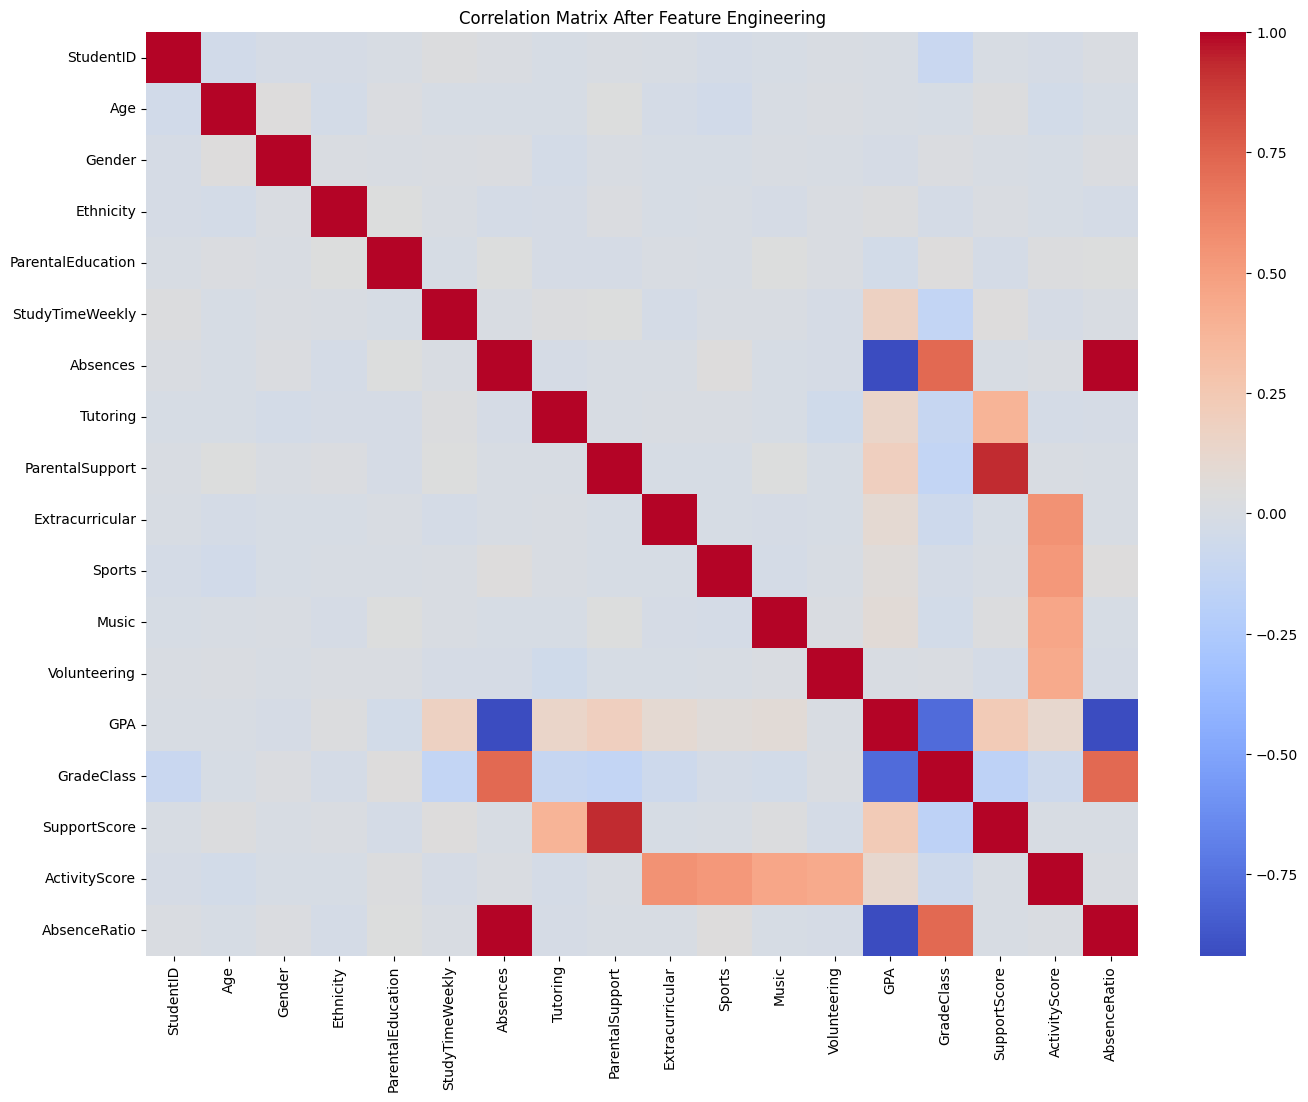

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix After Feature Engineering"
)

plt.show()